In [1]:
%matplotlib inline
import numpy as np
from scipy.integrate import solve_ivp
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [2]:
# Physics Engine and State Models
class SchwarzschildSpacetime:
    def __init__(self, M):
        self.M = M

    def null_geodesic(self, lmbda, y, b):
        t, r, phi, pr = y
        if r <= 2.001 * self.M:
            return [0, 0, 0, 0]
            
        dt_dl = 1.0 / (1.0 - 2.0 * self.M / r)
        dr_dl = pr
        dphi_dl = b / (r**2)
        dpr_dl = (b**2 / r**3) - (3.0 * self.M * b**2 / r**4)
        
        return [dt_dl, dr_dl, dphi_dl, dpr_dl]

    # Takes 'emission_angle' instead of 'b'
    # Increased 'points' to 5000 to improve temporal resolution and reduce gaps
    def trace_ray(self, source, emission_angle, lmbda_max=40, points=5000):
        y0, b = source.get_initial_conditions(self.M, emission_angle)
            
        def hit_horizon(lmbda, y, b_arg):
            return y[1] - 2.001 * self.M
        hit_horizon.terminal = True
        
        eval_points = np.linspace(0, lmbda_max, points)
        
        solution = solve_ivp(
            self.null_geodesic, (0, lmbda_max), y0, args=(b,),
            method='RK45', t_eval=eval_points, events=hit_horizon,
            rtol=1e-6, atol=1e-6
        )
        return solution

class LightSource:
    def __init__(self, r0, phi0, label="Lamp"):
        self.r0 = r0
        self.phi0 = phi0
        self.label = label
        
    def get_initial_conditions(self, M, emission_angle):
        # 1. Radial momentum is perfectly defined by the cosine of the angle
        # (Angle > 90 and < 270 naturally makes this negative/inward)
        pr0 = np.cos(emission_angle)
        
        # 2. Impact parameter 'b' derived from the sine of the angle
        time_dilation_factor = np.sqrt(1.0 - 2.0 * M / self.r0)
        b = (self.r0 / time_dilation_factor) * np.sin(emission_angle)
        
        return [0.0, self.r0, self.phi0, pr0], b

In [3]:
#  Data Analytics and Intersection Search
def find_intersections(data1, data2, eps_t=0.1, eps_s=0.25):
    """
    Finds points where light rays overlap in spacetime.
    Returns: intersections, death_times1, death_times2
    """
    data1_sorted = data1[data1[:, 0].argsort()]
    data2_sorted = data2[data2[:, 0].argsort()]
    t2_sorted = data2_sorted[:, 0]
    
    intersections = []
    consumed_rays1 = set()
    consumed_rays2 = set()
    
    death_times1 = {}
    death_times2 = {}
    
    for pt1 in data1_sorted:
        t1, x1, y1, ray1_id = pt1
        
        if ray1_id in consumed_rays1:
            continue
            
        idx_lower = np.searchsorted(t2_sorted, t1 - eps_t, side='left')
        idx_upper = np.searchsorted(t2_sorted, t1 + eps_t, side='right')
        
        if idx_lower == idx_upper:
            continue
            
        candidates = data2_sorted[idx_lower:idx_upper]
        
        dist_sq = (candidates[:, 1] - x1)**2 + (candidates[:, 2] - y1)**2
        valid_candidates = candidates[dist_sq <= eps_s**2]
        
        if len(valid_candidates) > 0:
            for cand in valid_candidates:
                ray2_id = cand[3]
                
                if ray2_id not in consumed_rays2:
                    intersections.append((x1, y1))
                    
                    consumed_rays1.add(ray1_id)
                    consumed_rays2.add(ray2_id)
                    
                    death_times1[ray1_id] = t1
                    death_times2[ray2_id] = cand[0]
                    break 
            
    return np.array(intersections), death_times1, death_times2

Tracing 1000 rays for Lamp 1...
Tracing 1000 rays for Lamp 2...
Finding spacetime intersections...
Plotting results...


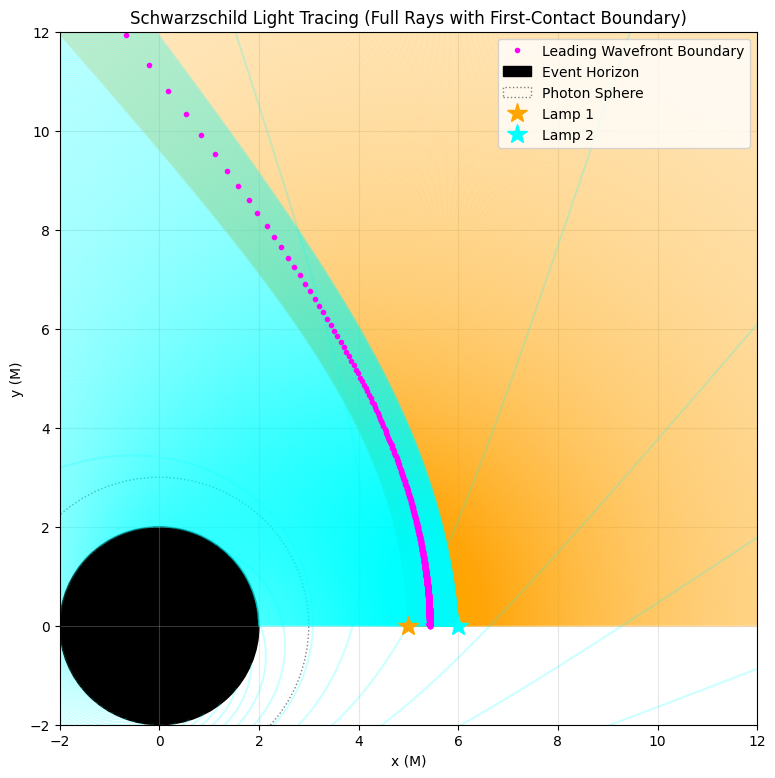

In [4]:
# Run simulation and plot
M = 1.0
spacetime = SchwarzschildSpacetime(M)

# Position your lamps
lamp1 = LightSource(r0=5.0 * M, phi0=0.0, label="Lamp 1")
lamp2 = LightSource(r0=6.0 * M, phi0=0.0, label="Lamp 2")

# ---------------------------------------------------------
# DEFINE EMISSION ANGLES 
# ---------------------------------------------------------
# Lamp 1: A narrow 30-degree cone pointing perfectly inward
angles_lamp1 = np.linspace(np.radians(0), np.radians(91), 1000)

# Lamp 2: A wider 90-degree cone pointing perfectly inward
angles_lamp2 = np.linspace(np.radians(95), np.radians(180), 1000)
# ---------------------------------------------------------

data_lamp1 = []
data_lamp2 = []
rays_lamp1 = {}
rays_lamp2 = {}

plt.figure(figsize=(9, 9))

print(f"Tracing {len(angles_lamp1)} rays for Lamp 1...")
for i, angle in enumerate(angles_lamp1):
    sol = spacetime.trace_ray(lamp1, angle)
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        ray_ids = np.full_like(t, i)
        
        data_lamp1.extend(np.column_stack((t, x, y, ray_ids)))
        rays_lamp1[i] = {'t': t, 'x': x, 'y': y}
        
print(f"Tracing {len(angles_lamp2)} rays for Lamp 2...")
for i, angle in enumerate(angles_lamp2):
    sol = spacetime.trace_ray(lamp2, angle)
    if sol is not None:
        t, r, phi = sol.y[0], sol.y[1], sol.y[2]
        x, y = r * np.cos(phi), r * np.sin(phi)
        ray_ids = np.full_like(t, i)
        
        data_lamp2.extend(np.column_stack((t, x, y, ray_ids)))
        rays_lamp2[i] = {'t': t, 'x': x, 'y': y}

data_lamp1 = np.array(data_lamp1)
data_lamp2 = np.array(data_lamp2)

print("Finding spacetime intersections...")
intersections, death_times1, death_times2 = find_intersections(data_lamp1, data_lamp2, eps_t=0.05, eps_s=0.1)

print("Plotting results...")

# --- NEW PLOTTING LOGIC (No Truncation) ---

# Plot the full rays for Lamp 1
for ray_id, ray in rays_lamp1.items():
    plt.plot(ray['x'], ray['y'], color='orange', alpha=0.2)

# Plot the full rays for Lamp 2
for ray_id, ray in rays_lamp2.items():
    plt.plot(ray['x'], ray['y'], color='cyan', alpha=0.2)

# ------------------------------------------

# Plot Intersections
if len(intersections) > 0:
    intersections = intersections[intersections[:, 0].argsort()]
    plt.plot(intersections[:, 0], intersections[:, 1], 'o', color='magenta', 
             linewidth=2.5, markersize=3, label='Leading Wavefront Boundary')
else:
    print("No intersections found.")

# Draw Environment
horizon = plt.Circle((0,0), 2*M, color='black', label='Event Horizon')
photon_sphere = plt.Circle((0,0), 3*M, color='gray', fill=False, linestyle=':', label='Photon Sphere')
plt.gca().add_patch(horizon)
plt.gca().add_patch(photon_sphere)

# Plot Lamps dynamically based on their object attributes
x1, y1 = lamp1.r0 * np.cos(lamp1.phi0), lamp1.r0 * np.sin(lamp1.phi0)
x2, y2 = lamp2.r0 * np.cos(lamp2.phi0), lamp2.r0 * np.sin(lamp2.phi0)
plt.plot(x1, y1, '*', color='orange', markersize=15, label=lamp1.label)
plt.plot(x2, y2, '*', color='cyan', markersize=15, label=lamp2.label)

plt.xlabel('x (M)')
plt.ylabel('y (M)')
plt.title('Schwarzschild Light Tracing (Full Rays with First-Contact Boundary)')
plt.xlim(-2, 12)
plt.ylim(-2, 12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()